In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup

from utils.colors import CMAP
from utils.plotting import save_plot
import matplotlib.patches as patches

from algorithms.cg_solvers import DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SETUP = TestProblemsSetup(n=64)
PROBLEM_PARAMS = SETUP.problem_params
PROBLEMS = SETUP.get_test_problems()
SEED = 15

In [2]:
def plot_multiple_f2(
        x_list, fig_name=None, shrink=0,
    ):
    pb = PROBLEMS['I']
    f_list = []
    for x in x_list:
        f = Function(pb['V_h'])
        f.vector()[:] = x
        f_list.append(f)

    fig, axes = plt.subplots(1, 2, figsize=(7,4))
    
    for ax, func, pid in zip(axes.flat, f_list, ('I', 'II')):
        plt.sca(ax)
        p = plot(func, cmap=CMAP)
        if shrink != 0: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        PBP = PROBLEM_PARAMS[pid]
        width, height = PBP['width'], PBP['height']
        x0s, y0s = PBP['x0'], PBP['y0']
        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)
    
    plt.tight_layout()
    save_plot(fig_name=fig_name)
    plt.show()


[##############################] 500/500
[##############################] 500/500
../../figures/diverged_solutions.png already exists


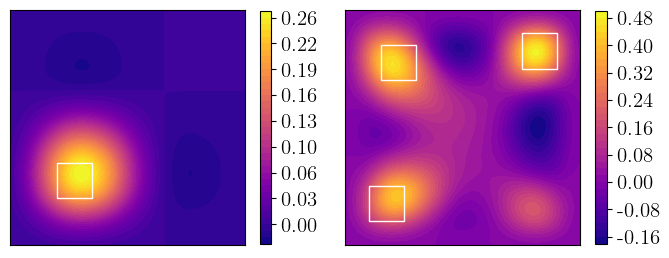

In [3]:
solutions, errors = [], []
for pid, mr in zip(['I', 'II'], [1, 2]):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd.solve(k=50)
    w = rsvd.weights()

    solver = DynamicalLowRankPCG(rsvd, pb['x'])
    x = solver.solve(
        pb['y'], w, lambda_=1e-4,
        max_rank=mr, preconditioner='ic-woodbury', restart_every=10, 
        rtol=0, max_iter=500
    )
    solutions.append(x)
    errors.append(solver.error.copy())



# Solutions which didn't converge well
plot_multiple_f2(solutions, shrink=0.655, fig_name='diverged_solutions')


[##############################] 25/25
[##############################] 25/25


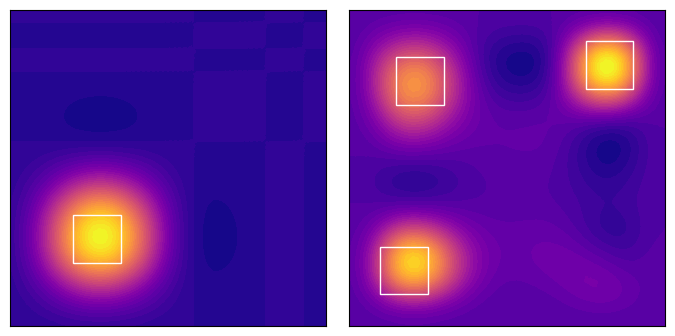

In [50]:

solutions2, errors2 = [], []
for i, (pid, mr) in enumerate(zip(['I', 'II'], [1, 2])):
    pb = PROBLEMS[pid]

    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd.solve(k=50, seed=SEED)
    w = rsvd.weights()

    solver = DynamicalLowRankPCG(rsvd, pb['x'])

    X0 = solver.vec_to_matrix(solutions[i])

    x = solver.solve(
        pb['y'], w,
        lambda_=1e-4, max_rank=mr, preconditioner='ic',
        X0=X0, max_iter=25
    )

    solutions2.append(x)
    errors2.append(solver.error.copy())

plot_multiple_f2(solutions2)

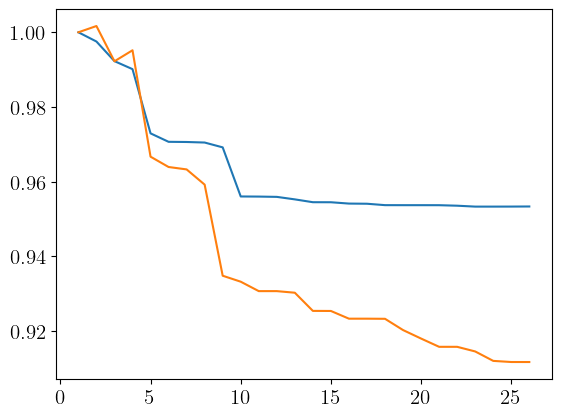

In [51]:
fig, ax = plt.subplots(1, 1)
for e in errors2:
    ax.plot(np.arange(1,len(e)+1), e)